# STEP 10.1 — Attention Visualization

Notebook này trực quan hóa attention weights của Transformer NMT.

Ta sẽ xem 3 loại attention:

1. Encoder self-attention.
2. Decoder self-attention.
3. Decoder cross-attention.

Notebook dùng teacher-forced target để trực quan hóa cross-attention. Hàng thứ `t` của decoder attention tương ứng với decoder input token ở vị trí `t`, còn logits tại vị trí đó dự đoán target token tiếp theo.

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd().resolve()

while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "configs" / "base.yaml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "configs" / "base.yaml").exists():
    raise FileNotFoundError(
        "Could not locate project root containing configs/base.yaml."
    )

os.chdir(PROJECT_ROOT)

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Config path :", PROJECT_ROOT / "configs" / "base.yaml")

Project root: /home/phat/AI_Project/transformer-en-vi-translation
Config path : /home/phat/AI_Project/transformer-en-vi-translation/configs/base.yaml


In [2]:
from config import load_config
from data.tokenizer import load_tokenizers
from inference.translate import load_model

config = load_config()

data_config = config["data"]
model_config = config["model"]
training_config = config["training"]
inference_config = config["inference"]

TEST_PATH = (
    Path(data_config["processed_dir"])
    / data_config["splits"]["test"]["output_file"]
)

CHECKPOINT_PATH = (
    Path(training_config["checkpoint_dir"])
    / inference_config["checkpoint_name"]
)

print("Model configuration:")
print(model_config)
print()
print("Checkpoint:", CHECKPOINT_PATH)
print("Test data :", TEST_PATH)

Model configuration:
{'d_model': 256, 'num_heads': 8, 'd_ff': 1024, 'num_encoder_layers': 4, 'num_decoder_layers': 4, 'dropout': 0.1, 'max_len': 512}

Checkpoint: checkpoints/transformer_256x4/best.pt
Test data : data/processed/test.jsonl


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

en_tokenizer, vi_tokenizer = load_tokenizers()

model = load_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=device,
    src_vocab_size=en_tokenizer.vocab_size(),
    tgt_vocab_size=vi_tokenizer.vocab_size(),
    src_pad_id=en_tokenizer.pad_id(),
    tgt_pad_id=vi_tokenizer.pad_id(),
)

model.eval()

print("Device:", device)
print("Model loaded successfully.")

Device: cuda
Model loaded successfully.


## 1. Load a test sentence

Đổi `SAMPLE_INDEX` để xem attention của các câu khác nhau.

In [4]:
SAMPLE_INDEX = 1

samples = []

with TEST_PATH.open("r", encoding="utf-8") as file:
    for line in file:
        record = json.loads(line)
        samples.append((record["src"], record["tgt"]))

if not 0 <= SAMPLE_INDEX < len(samples):
    raise IndexError(
        f"SAMPLE_INDEX must be in [0, {len(samples) - 1}]."
    )

source_text, target_text = samples[SAMPLE_INDEX]

print("Source    :", source_text)
print("Reference :", target_text)

Source    : And I was very proud .
Reference : Tôi đã rất tự hào về đất nước tôi .


## 2. Tokenize source and target

Source:

```text
[BOS] + source pieces + [EOS]
```

Teacher-forced decoder input:

```text
[BOS] + target pieces
```

Target-to-predict:

```text
target pieces + [EOS]
```

In [6]:
src_pieces = en_tokenizer.encode_pieces(source_text)
tgt_pieces = vi_tokenizer.encode_pieces(target_text)

src_labels = ["<BOS>"] + src_pieces + ["<EOS>"]
tgt_decoder_labels = ["<BOS>"] + tgt_pieces
tgt_target_labels = tgt_pieces + ["<EOS>"]

src_ids = en_tokenizer.encode_ids(
    source_text,
    add_bos=True,
    add_eos=True,
)

tgt_ids = vi_tokenizer.encode_ids(
    target_text,
    add_bos=True,
    add_eos=True,
)

decoder_input_ids = tgt_ids[:-1]
target_ids = tgt_ids[1:]

src_tensor = torch.tensor(
    [src_ids],
    dtype=torch.long,
    device=device,
)

decoder_input_tensor = torch.tensor(
    [decoder_input_ids],
    dtype=torch.long,
    device=device,
)

target_tensor = torch.tensor(
    [target_ids],
    dtype=torch.long,
    device=device,
)

print("Source pieces:")
print(src_labels)

print("\nDecoder input pieces:")
print(tgt_decoder_labels)

print("\nTarget-to-predict pieces:")
print(tgt_target_labels)

print("\nShapes:")
print("src_ids           :", src_tensor.shape)
print("decoder_input_ids :", decoder_input_tensor.shape)
print("target_ids        :", target_tensor.shape)

Source pieces:
['<BOS>', '▁And', '▁I', '▁was', '▁very', '▁proud', '▁.', '<EOS>']

Decoder input pieces:
['<BOS>', '▁Tôi', '▁đã', '▁rất', '▁tự', '▁hào', '▁về', '▁đất', '▁nước', '▁tôi', '▁.']

Target-to-predict pieces:
['▁Tôi', '▁đã', '▁rất', '▁tự', '▁hào', '▁về', '▁đất', '▁nước', '▁tôi', '▁.', '<EOS>']

Shapes:
src_ids           : torch.Size([1, 8])
decoder_input_ids : torch.Size([1, 11])
target_ids        : torch.Size([1, 11])


## 3. Run encoder + decoder and collect attention

Expected shapes:

```text
Encoder attention:        [B, H, S_src, S_src]
Decoder self-attention:   [B, H, S_tgt, S_tgt]
Decoder cross-attention:  [B, H, S_tgt, S_src]
```

Here `B = 1`.

In [7]:
with torch.no_grad():
    memory, encoder_attention = model.encode(src_tensor)

    (
        logits,
        decoder_self_attention,
        decoder_cross_attention,
    ) = model.decode(
        tgt_ids=decoder_input_tensor,
        memory=memory,
        src_ids=src_tensor,
    )

print("Memory shape:", memory.shape)
print("Logits shape:", logits.shape)

print("\nEncoder layers:",
      len(encoder_attention))
print("Decoder layers:",
      len(decoder_self_attention))

print("\nEncoder attention[0]:",
      encoder_attention[0].shape)

print("Decoder self-attention[0]:",
      decoder_self_attention[0].shape)

print("Decoder cross-attention[0]:",
      decoder_cross_attention[0].shape)

Memory shape: torch.Size([1, 8, 256])
Logits shape: torch.Size([1, 11, 8000])

Encoder layers: 4
Decoder layers: 4

Encoder attention[0]: torch.Size([1, 8, 8, 8])
Decoder self-attention[0]: torch.Size([1, 8, 11, 11])
Decoder cross-attention[0]: torch.Size([1, 8, 11, 8])


## 4. Helper function for heatmaps

In [8]:
def plot_attention(
    attention: torch.Tensor,
    x_labels: list[str],
    y_labels: list[str],
    title: str,
    xlabel: str,
    ylabel: str,
    figsize: tuple[int, int] = (12, 8),
) -> None:
    """Plot one attention matrix as a heatmap."""
    matrix = attention.detach().float().cpu().numpy()

    if matrix.shape != (len(y_labels), len(x_labels)):
        raise ValueError(
            "Attention shape does not match labels: "
            f"{matrix.shape} vs "
            f"({len(y_labels)}, {len(x_labels)})."
        )

    fig, ax = plt.subplots(figsize=figsize)

    image = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(
        x_labels,
        rotation=60,
        ha="right",
    )

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)

    fig.colorbar(
        image,
        ax=ax,
        label="Attention weight",
    )

    fig.tight_layout()
    plt.show()

## 5. Encoder self-attention

`row = query/source token`

`column = key/source token`

Ta xem một head cụ thể và trung bình tất cả heads.

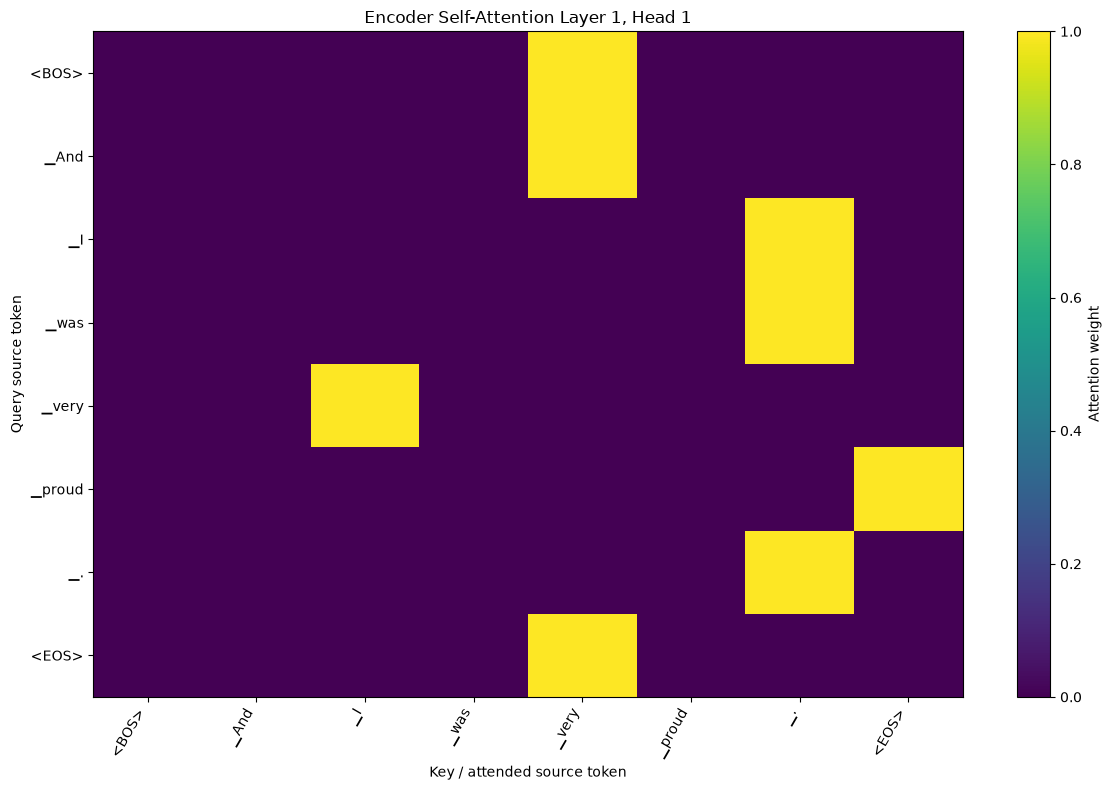

In [9]:
ENCODER_LAYER = 0
ENCODER_HEAD = 0

encoder_weights = encoder_attention[ENCODER_LAYER][0]
selected_encoder_head = encoder_weights[ENCODER_HEAD]

plot_attention(
    attention=selected_encoder_head,
    x_labels=src_labels,
    y_labels=src_labels,
    title=(
        f"Encoder Self-Attention "
        f"Layer {ENCODER_LAYER + 1}, "
        f"Head {ENCODER_HEAD + 1}"
    ),
    xlabel="Key / attended source token",
    ylabel="Query source token",
)

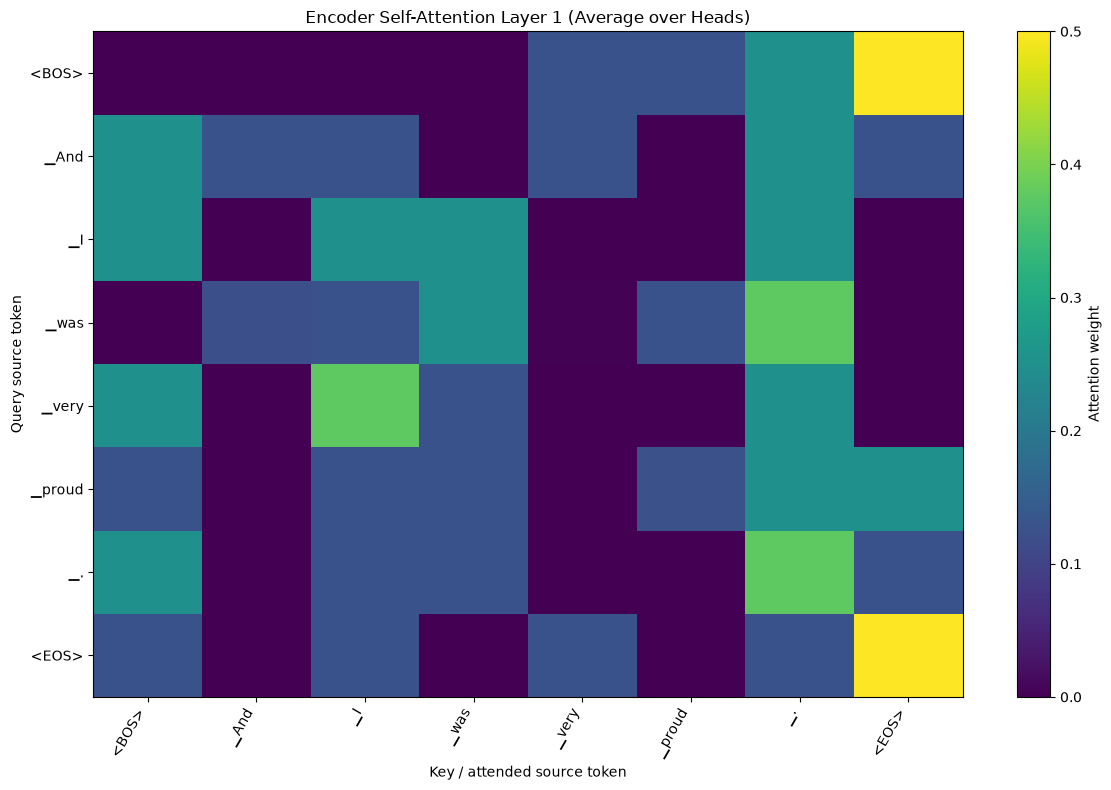

In [10]:
encoder_average = encoder_weights.mean(dim=0)

plot_attention(
    attention=encoder_average,
    x_labels=src_labels,
    y_labels=src_labels,
    title=(
        f"Encoder Self-Attention "
        f"Layer {ENCODER_LAYER + 1} "
        f"(Average over Heads)"
    ),
    xlabel="Key / attended source token",
    ylabel="Query source token",
)

## 6. Decoder self-attention

Decoder self-attention có causal mask, nên future positions phải có attention weight bằng 0.

Ta xem một head cụ thể và trung bình các heads.

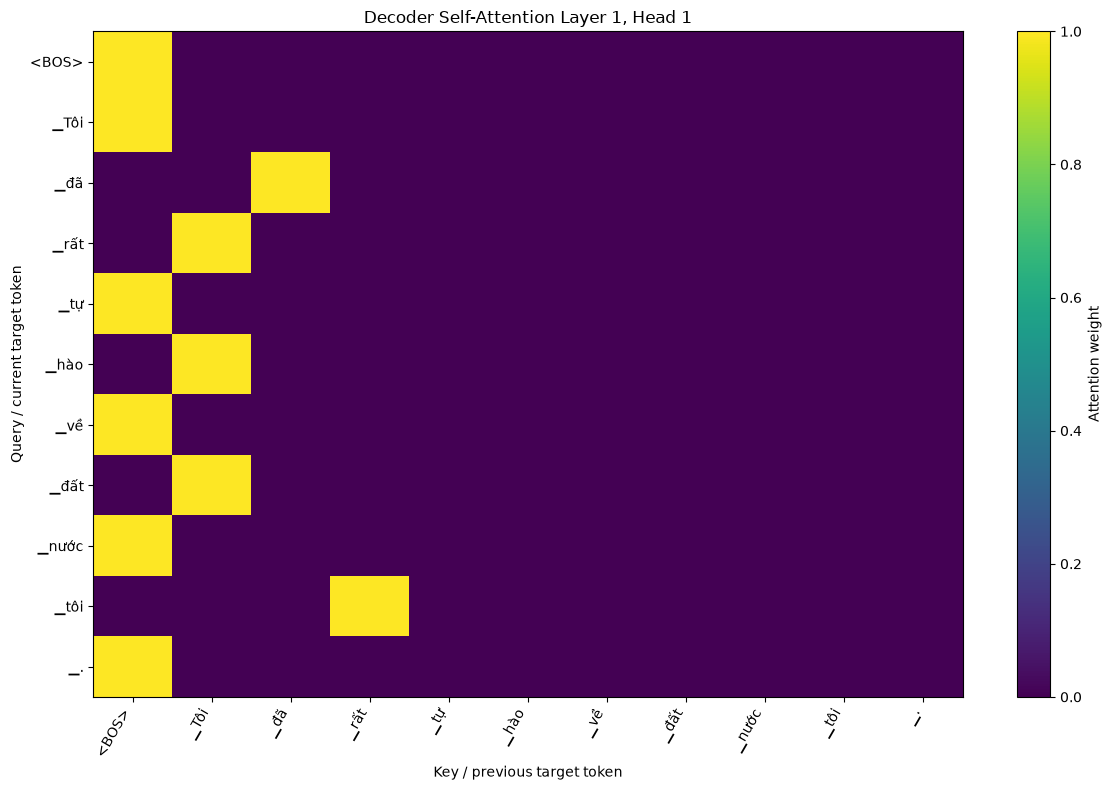

In [11]:
DECODER_LAYER = 0
DECODER_HEAD = 0

decoder_self_weights = decoder_self_attention[DECODER_LAYER][0]
selected_decoder_self_head = decoder_self_weights[DECODER_HEAD]

plot_attention(
    attention=selected_decoder_self_head,
    x_labels=tgt_decoder_labels,
    y_labels=tgt_decoder_labels,
    title=(
        f"Decoder Self-Attention "
        f"Layer {DECODER_LAYER + 1}, "
        f"Head {DECODER_HEAD + 1}"
    ),
    xlabel="Key / previous target token",
    ylabel="Query / current target token",
)

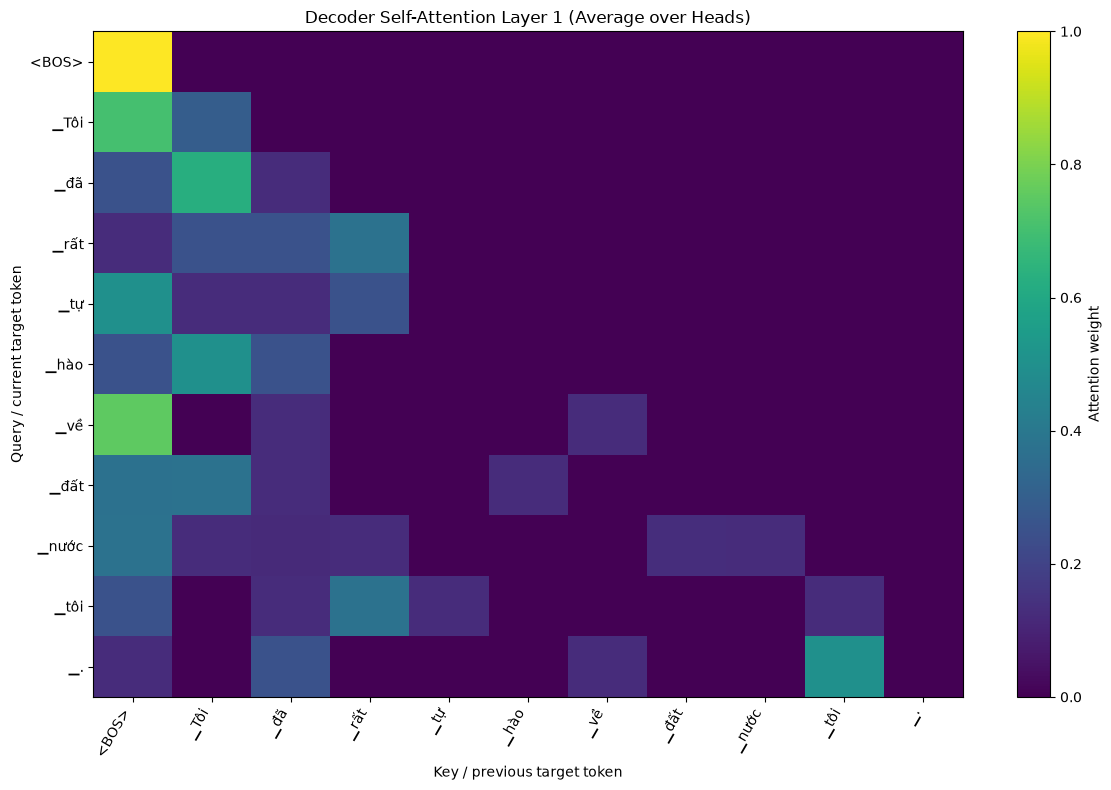

In [12]:
decoder_self_average = decoder_self_weights.mean(dim=0)

plot_attention(
    attention=decoder_self_average,
    x_labels=tgt_decoder_labels,
    y_labels=tgt_decoder_labels,
    title=(
        f"Decoder Self-Attention "
        f"Layer {DECODER_LAYER + 1} "
        f"(Average over Heads)"
    ),
    xlabel="Key / previous target token",
    ylabel="Query / current target token",
)

## 7. Decoder cross-attention

Shape:

```text
[B, H, S_tgt, S_src]
```

Interpretation:

- row = decoder target representation
- column = source token

Ta dùng teacher forcing, nên hàng `t` ứng với decoder input token ở vị trí `t`. Cross-attention cho biết target-side representation đang tham chiếu source như thế nào.

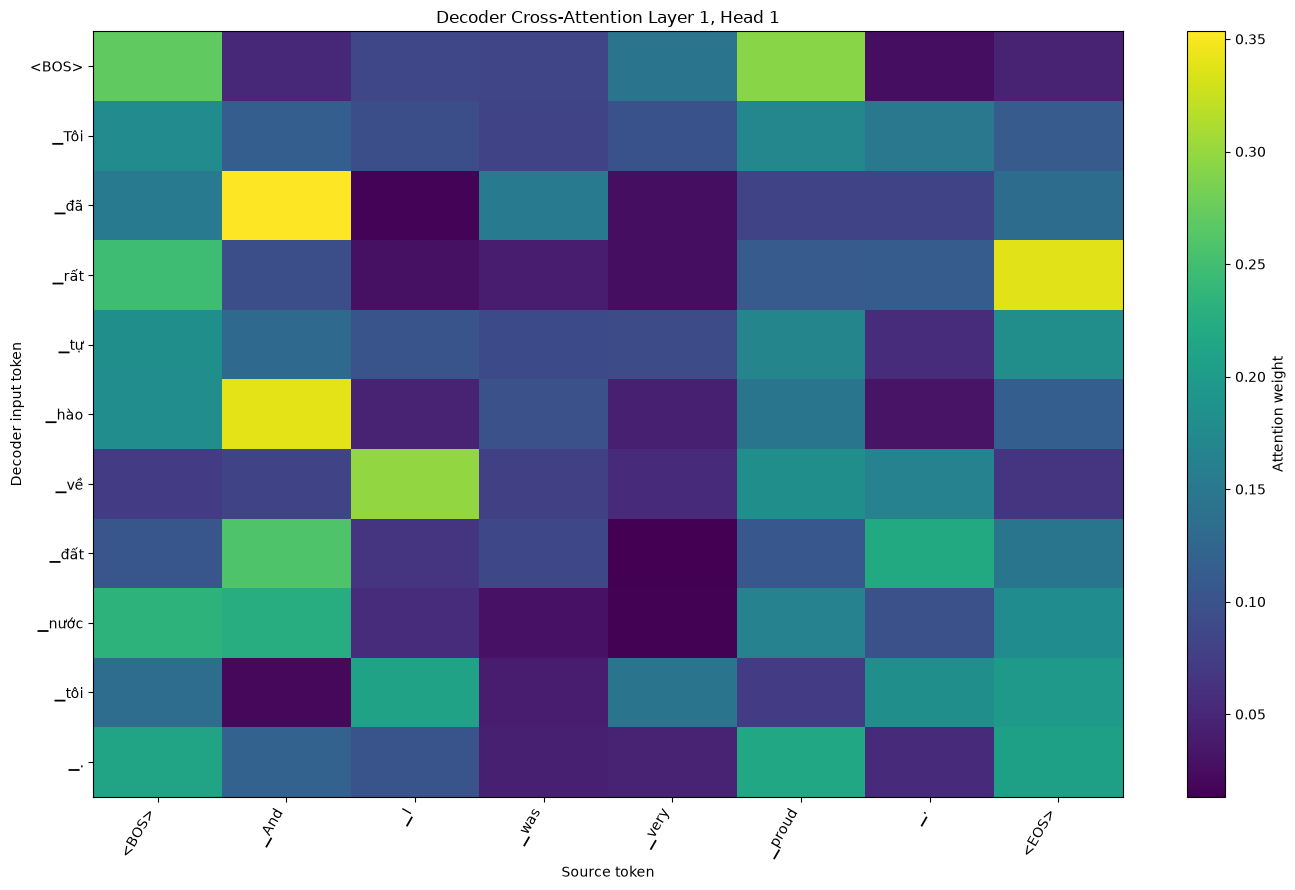

In [13]:
CROSS_LAYER = 0
CROSS_HEAD = 0

cross_weights = decoder_cross_attention[CROSS_LAYER][0]
selected_cross_head = cross_weights[CROSS_HEAD]

plot_attention(
    attention=selected_cross_head,
    x_labels=src_labels,
    y_labels=tgt_decoder_labels,
    title=(
        f"Decoder Cross-Attention "
        f"Layer {CROSS_LAYER + 1}, "
        f"Head {CROSS_HEAD + 1}"
    ),
    xlabel="Source token",
    ylabel="Decoder input token",
    figsize=(14, 9),
)

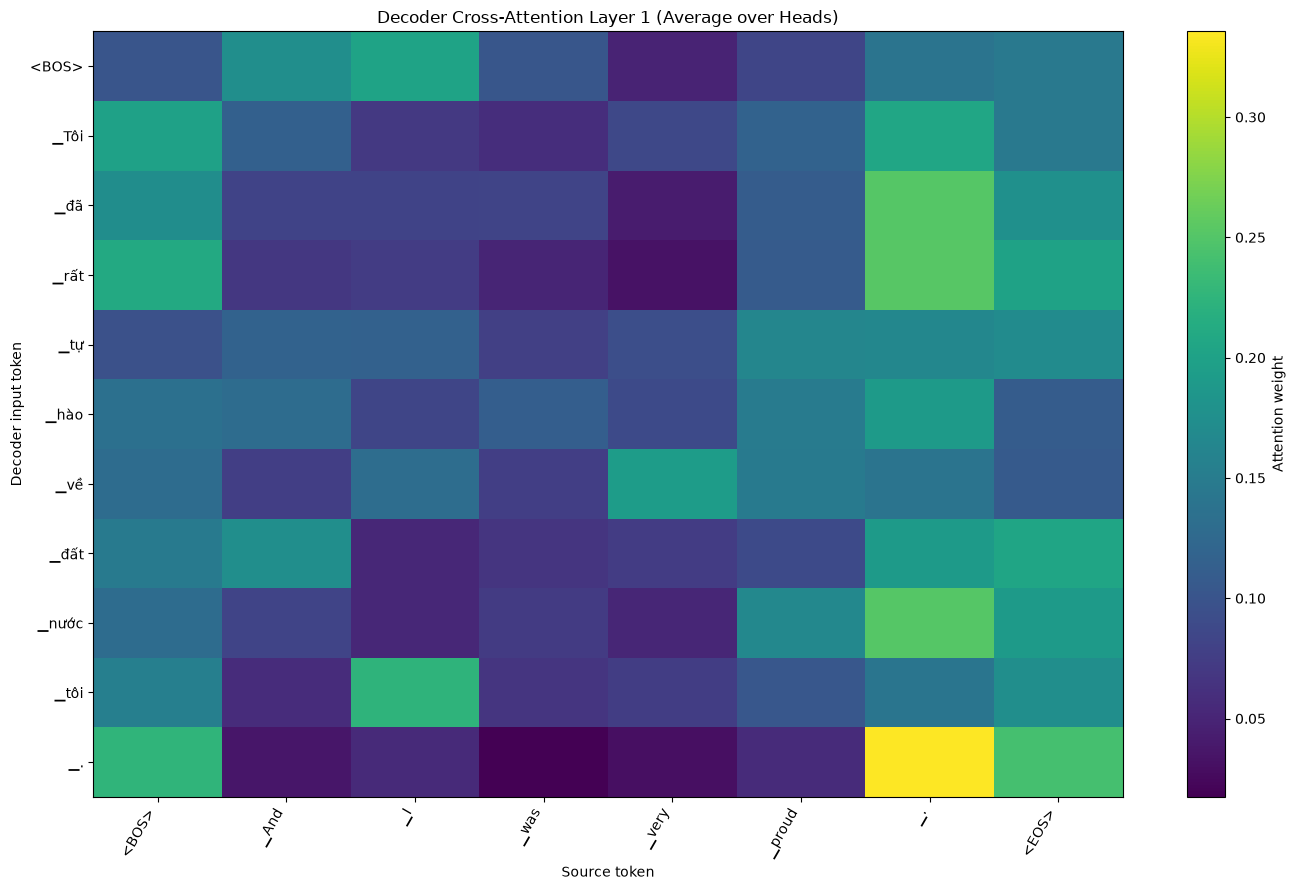

In [14]:
cross_average = cross_weights.mean(dim=0)

plot_attention(
    attention=cross_average,
    x_labels=src_labels,
    y_labels=tgt_decoder_labels,
    title=(
        f"Decoder Cross-Attention "
        f"Layer {CROSS_LAYER + 1} "
        f"(Average over Heads)"
    ),
    xlabel="Source token",
    ylabel="Decoder input token",
    figsize=(14, 9),
)

## 8. Simple source-target alignment view

Lấy source token có attention lớn nhất cho từng decoder input token.

In [15]:
best_source_indices = cross_average.argmax(dim=1).tolist()

print(
    f"{'Target token':<20}"
    f"{'Best source token':<20}"
    f"{'Attention':>12}"
)
print("-" * 55)

for row_index, target_token in enumerate(tgt_decoder_labels):
    source_index = best_source_indices[row_index]
    weight = float(cross_average[row_index, source_index])

    print(
        f"{target_token:<20}"
        f"{src_labels[source_index]:<20}"
        f"{weight:>12.4f}"
    )

Target token        Best source token      Attention
-------------------------------------------------------
<BOS>               ▁I                        0.2021
▁Tôi                ▁.                        0.2063
▁đã                 ▁.                        0.2517
▁rất                ▁.                        0.2532
▁tự                 <EOS>                     0.1712
▁hào                ▁.                        0.1906
▁về                 ▁very                     0.1938
▁đất                <EOS>                     0.2039
▁nước               ▁.                        0.2519
▁tôi                ▁I                        0.2249
▁.                  ▁.                        0.3356
